In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
root_dir = ".."

In [4]:
results_df = pd.read_csv(f"{root_dir}/datasets/analysis-results.csv")
results_df

,project_name,Project,Antipattern,File,Line from,Line to,Code fragment,Explanation
0,4el1k/Spring-Api-Hibernate-JOOQ,4el1k_Spring-Api-Hibernate-JOOQ,ID Required,spring-impl/src/main/java/ru/itis/model/jooq/s...,56,56,"public final TableField<AccountRecord, UUID> I...",The primary key column is generically named 'i...
1,4el1k/Spring-Api-Hibernate-JOOQ,4el1k_Spring-Api-Hibernate-JOOQ,Keyless Entry,spring-impl/src/main/java/ru/itis/model/jooq/s...,58,58,public final TableField<AssociativeListenerMus...,The MUSIC_ID column appears to reference the M...
2,4el1k/Spring-Api-Hibernate-JOOQ,4el1k_Spring-Api-Hibernate-JOOQ,ID Required,spring-impl/src/main/java/ru/itis/model/jooq/s...,58,58,"public final TableField<AuthorRecord, UUID> ID...",The table has a synthetic primary key named 'i...
3,4el1k/Spring-Api-Hibernate-JOOQ,4el1k_Spring-Api-Hibernate-JOOQ,ID Required,spring-impl/src/main/java/ru/itis/model/jooq/s...,58,58,"public final TableField<ListenerRecord, UUID> ...",The table has a synthetic primary key named 'i...
4,4el1k/Spring-Api-Hibernate-JOOQ,4el1k_Spring-Api-Hibernate-JOOQ,ID Required,spring-impl/src/main/java/ru/itis/model/jooq/s...,58,58,"public final TableField<ManagerRecord, UUID> I...",The primary key column is generically named 'i...
...,...,...,...,...,...,...,...,...
15926,zodac-personal/folding-stats,zodac-personal_folding-stats,Implicit Columns,folding-stats-jar/src/main/java/net/zodac/fold...,870,872,final var query = queryContext\n .select()\...,Using `select()` without specifying columns fe...
15927,zodac-personal/folding-stats,zodac-personal_folding-stats,Implicit Columns,folding-stats-jar/src/main/java/net/zodac/fold...,921,923,final var query = queryContext\n .select()\...,Using `select()` without specifying columns fe...
15928,zodac-personal/folding-stats,zodac-personal_folding-stats,Implicit Columns,folding-stats-jar/src/main/java/net/zodac/fold...,962,964,final var query = queryContext\n .select()\...,Using `select()` without specifying columns fe...
15929,zodac-personal/folding-stats,zodac-personal_folding-stats,Implicit Columns,folding-stats-jar/src/main/java/net/zodac/fold...,1112,1114,final var query = queryContext\n .select()\...,Using `select()` without specifying columns fe...


In [5]:
statements_df = pd.read_csv(f"{root_dir}/datasets/project-statement-counts.csv")
statements_df

,name,count
0,4el1k/Spring-Api-Hibernate-JOOQ,40
1,66xc1/lazy-punch,22
2,ABCLV/ABLV_IngSW,4
3,APSfurizon/fz-backend,170
4,AWS-Cloud-Community-LPU/mailing-service,4
...,...,...
597,zhouzhaodong/springboot,22
598,zhuyb0614/graph-batis,1
599,zigzag191/java-backend-course-2024,27
600,zjxkenshine/codedemo,83


In [7]:
import pandas as pd

# 1. Calculate the total number of SQL statements from statements_df
total_sql_statements = statements_df["count"].sum()

# 2. Create the matrix of counts per project
counts_per_project = (
    results_df.groupby(["Antipattern", "Project"]).size().unstack(fill_value=0)
)

# 3. Create the summary
summary = pd.DataFrame(
    {
        "Total Count": counts_per_project.sum(axis=1),
        "Project Count": (counts_per_project > 0).sum(axis=1),
        "Avg Per Project": counts_per_project.mean(axis=1),
    }
)

summary["Avg Per Containing Project"] = (
    summary["Total Count"] / summary["Project Count"]
)

# 4. Add the Smell Density columns
summary["Per 10 Statements"] = (summary["Total Count"] / total_sql_statements) * 10
summary["Per 100 Statements"] = (
    summary["Total Count"] / total_sql_statements
) * 100

# 5. Add a "Total" summary row
# We calculate specific logic for the totals to ensure averages remain correct
total_row = pd.Series(
    {
        "Total Count": summary["Total Count"].sum(),
        "Project Count": (
            counts_per_project.sum(axis=0) > 0
        ).sum(),  # Total unique projects with any smell
        "Avg Per Project": summary["Total Count"].sum()
        / counts_per_project.shape[1],
    },
    name="Total",
)

# Calculate derived metrics for the total row
total_row["Avg Per Containing Project"] = (
    total_row["Total Count"] / total_row["Project Count"]
)
total_row["Per 10 Statements"] = (
    total_row["Total Count"] / total_sql_statements
) * 10
total_row["Per 100 Statements"] = (
    total_row["Total Count"] / total_sql_statements
) * 100

# Append the row
summary = pd.concat([summary, total_row.to_frame().T])

print(f"Total SQL Statements analyzed: {total_sql_statements}")
print("\nAntipattern Statistics with Density:")
summary

Total SQL Statements analyzed: 33220

Antipattern Statistics with Density:


,Total Count,Project Count,Avg Per Project,Avg Per Containing Project,Per 10 Statements,Per 100 Statements
31 Flavors,390.0,87.0,0.648918,4.482759,0.117399,1.173992
Beware of the Unknown,1256.0,205.0,2.089850,6.126829,0.378085,3.780855
ID Required,3597.0,523.0,5.985025,6.877629,1.082781,10.827815
Implicit Columns,7289.0,535.0,12.128120,13.624299,2.194160,21.941601
Keyless Entry,2153.0,200.0,3.582363,10.765000,0.648104,6.481036
Poor Man's Search Engine,583.0,114.0,0.970050,5.114035,0.175497,1.754967
Rounding Errors,663.0,86.0,1.103161,7.709302,0.199579,1.995786
Total,15931.0,601.0,26.507488,26.507488,4.795605,47.956051


/home/kristo/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


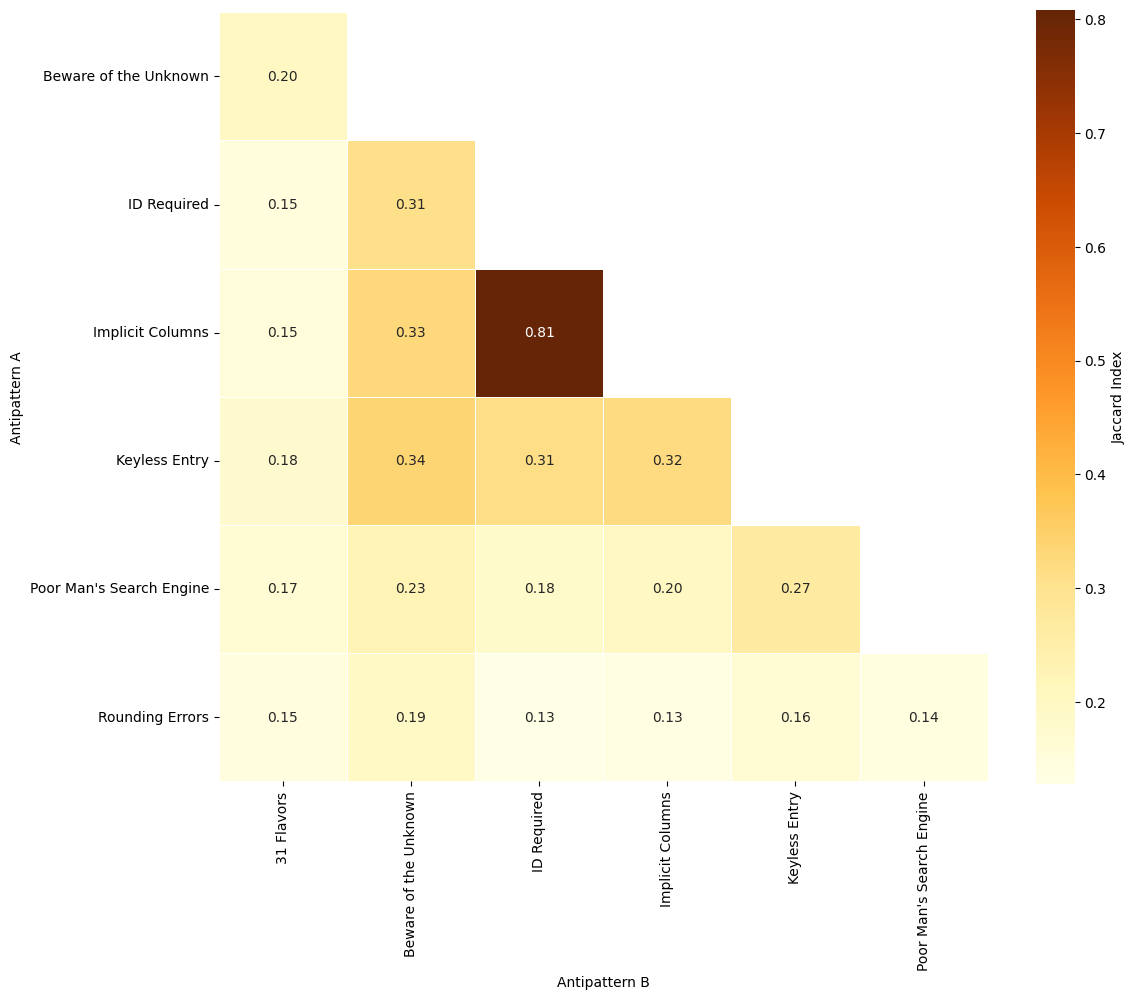

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances

# 1. Create binary matrix (Project level)
# This marks an antipattern as 1 if it appears at least once in the project
project_matrix = (
    results_df.groupby(["Project", "Antipattern"])
    .size()
    .unstack(fill_value=0)
    .astype(bool)
    .astype(int)
)

# 2. Calculate Jaccard Similarity for projects
jaccard_proj_sim = 1 - pairwise_distances(
    project_matrix.T.to_numpy(), 
    metric="jaccard"
)

# 3. Convert to DataFrame
jaccard_proj_df = pd.DataFrame(
    jaccard_proj_sim, 
    index=project_matrix.columns, 
    columns=project_matrix.columns
)

# 4. Create the mask for the upper triangle and diagonal
mask = np.triu(np.ones_like(jaccard_proj_df, dtype=bool))

# 5. Slice to hide the empty first row and empty last column
plot_df = jaccard_proj_df.iloc[1:, :-1]
plot_mask = mask[1:, :-1]

# 6. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    plot_df, 
    mask=plot_mask,
    annot=True, 
    cmap="YlOrBr", 
    fmt=".2f", 
    square=True,
    linewidths=.5,
    cbar_kws={'label': 'Jaccard Index'}
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.tight_layout()
plt.show()

/home/kristo/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


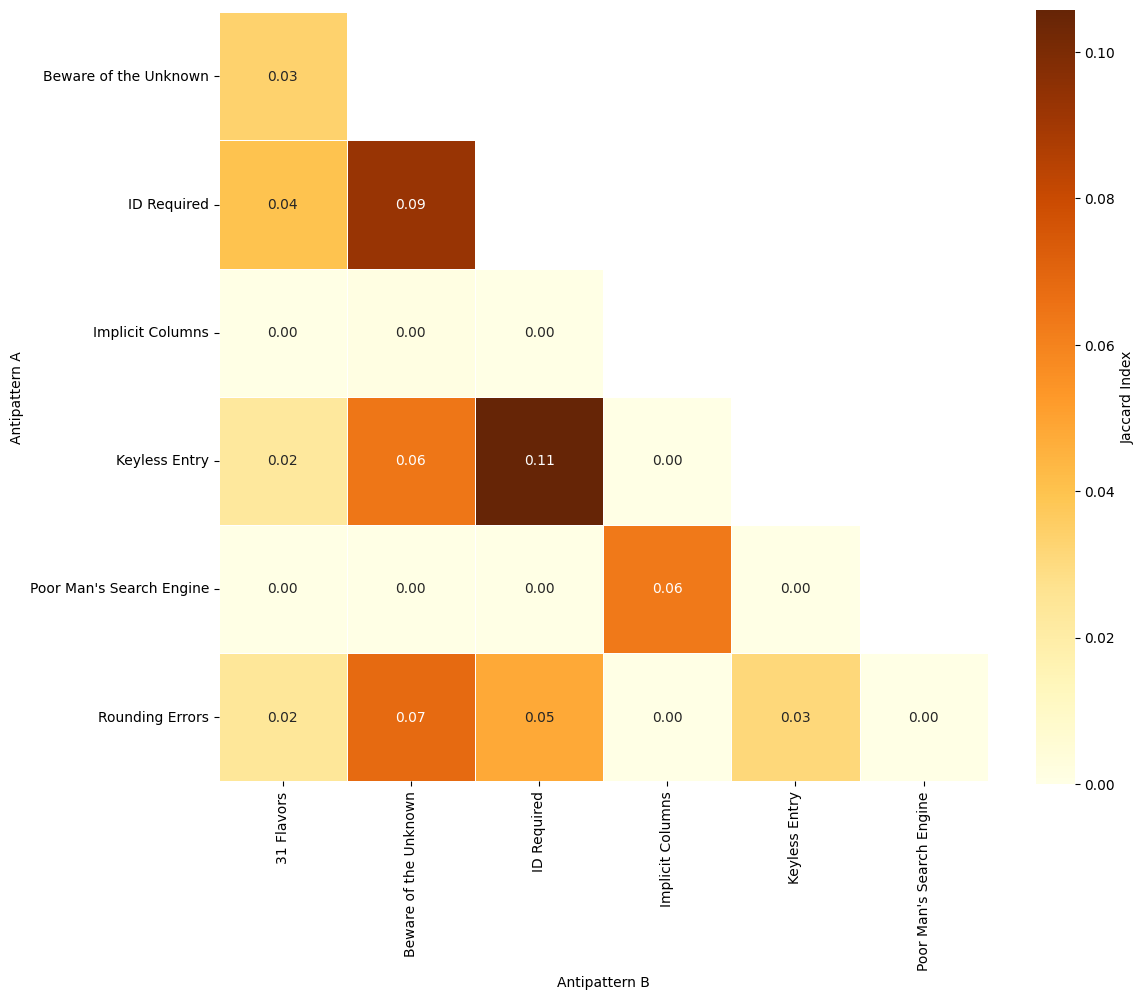

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances

# 1. Create binary matrix (File level)
file_matrix = (
    results_df.groupby(["Project", "File", "Antipattern"])
    .size()
    .unstack(fill_value=0)
    .astype(bool)
    .astype(int)
)

# 2. Calculate Jaccard Similarity
jaccard_file_sim = 1 - pairwise_distances(
    file_matrix.T.to_numpy(), 
    metric="jaccard"
)

# 3. Convert to DataFrame
jaccard_file_df = pd.DataFrame(
    jaccard_file_sim, 
    index=file_matrix.columns, 
    columns=file_matrix.columns
)

# 4. Create the mask for the upper triangle and diagonal
mask = np.triu(np.ones_like(jaccard_file_df, dtype=bool))

# 5. Slice the dataframe and the mask
# [1:] removes the first row, [:-1] removes the last column
plot_df = jaccard_file_df.iloc[1:, :-1]
plot_mask = mask[1:, :-1]

# 6. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    plot_df, 
    mask=plot_mask,
    annot=True, 
    cmap="YlOrBr", 
    fmt=".2f", 
    square=True,
    linewidths=.5,
    cbar_kws={'label': 'Jaccard Index'}
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.tight_layout()
plt.show()

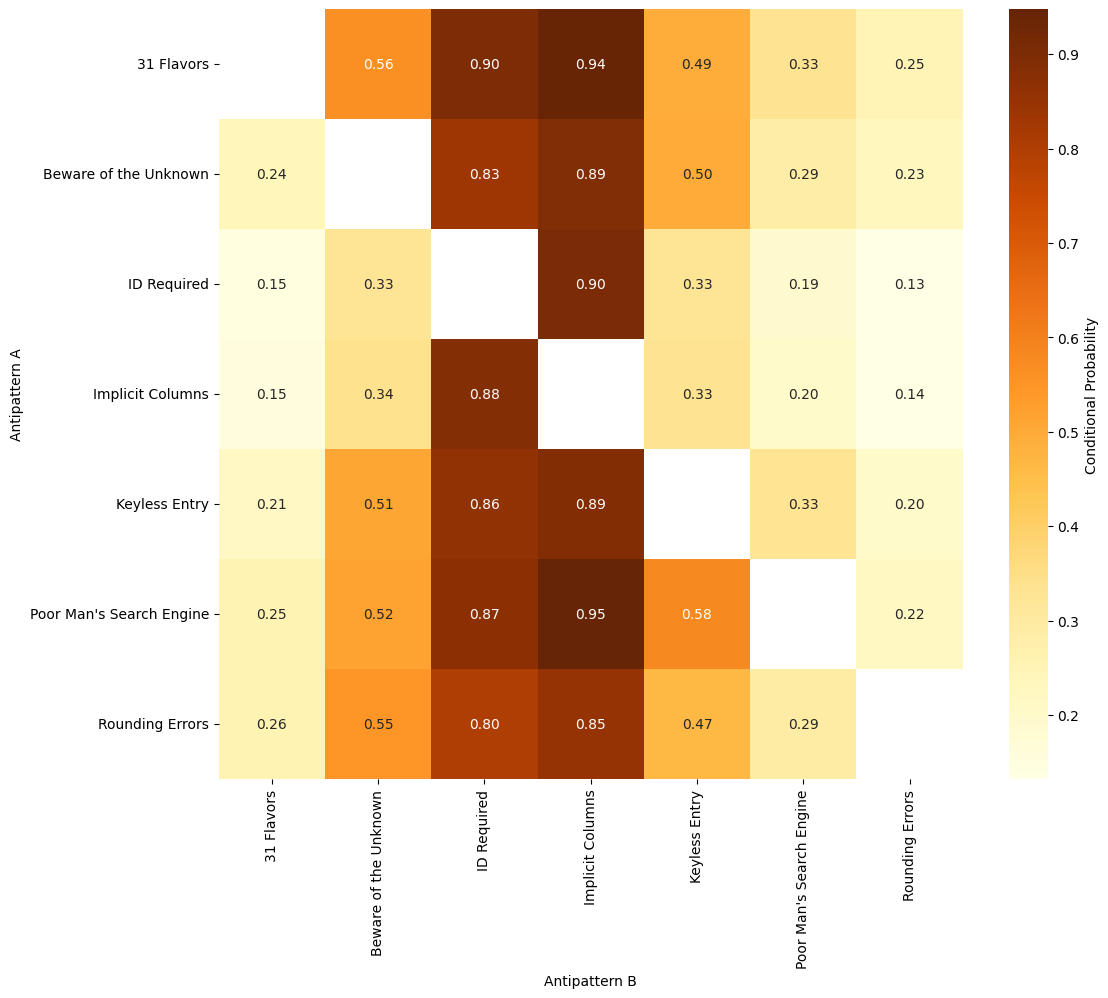

In [63]:
# 1. Create binary matrix (Project level)
project_matrix = (
    results_df.groupby(["Project", "Antipattern"])
    .size()
    .unstack(fill_value=0)
    .astype(bool)
    .astype(int)
)

# 2. Calculate Asymmetric Co-occurrence (Conditional Probability)
# Matrix multiplication gives the intersection counts
intersection_counts = project_matrix.T.dot(project_matrix)

# Divide each row by the total occurrences of that row's antipattern
# This calculates: P(Column | Row)
row_sums = project_matrix.sum(axis=0)
asymmetric_matrix = intersection_counts.div(row_sums, axis=0)

# 3. Mask the diagonal (optional, since P(A|A) is always 1.0)
mask = np.eye(len(asymmetric_matrix), dtype=bool)

# 4. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    asymmetric_matrix, 
    mask=mask,
    annot=True, 
    cmap="YlOrBr", 
    fmt=".2f",
    cbar_kws={'label': 'Conditional Probability'}
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.show()

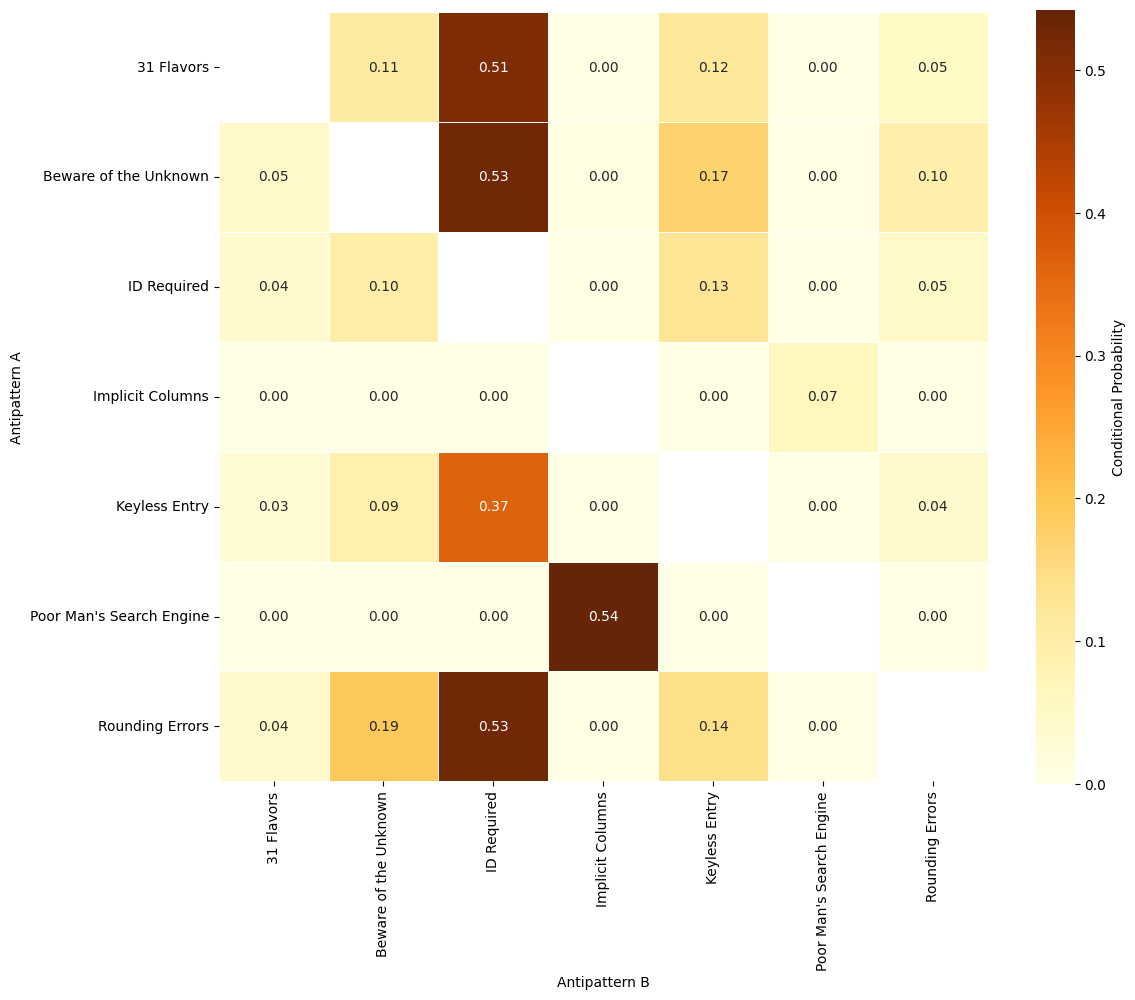

In [64]:
# 1. Create binary matrix (File level)
# Grouping by Project and File ensures uniqueness
file_matrix = (
    results_df.groupby(["Project", "File", "Antipattern"])
    .size()
    .unstack(fill_value=0)
    .astype(bool)
    .astype(int)
)

# 2. Calculate Intersections (How many files have both?)
# This results in a square matrix of raw counts
intersections = file_matrix.T.dot(file_matrix)

# 3. Calculate Conditional Probability: P(Column | Row)
# We divide the intersection count by the total count of the "Row" antipattern
row_totals = file_matrix.sum(axis=0)
asymmetric_file_matrix = intersections.div(row_totals, axis=0)

# 4. Mask the diagonal
# P(A|A) is always 1.0, masking it helps highlight relationships between different smells
mask = np.eye(len(asymmetric_file_matrix), dtype=bool)

# 5. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    asymmetric_file_matrix, 
    mask=mask,
    annot=True, 
    cmap="YlOrBr", 
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={'label': 'Conditional Probability'}
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.tight_layout()
plt.show()

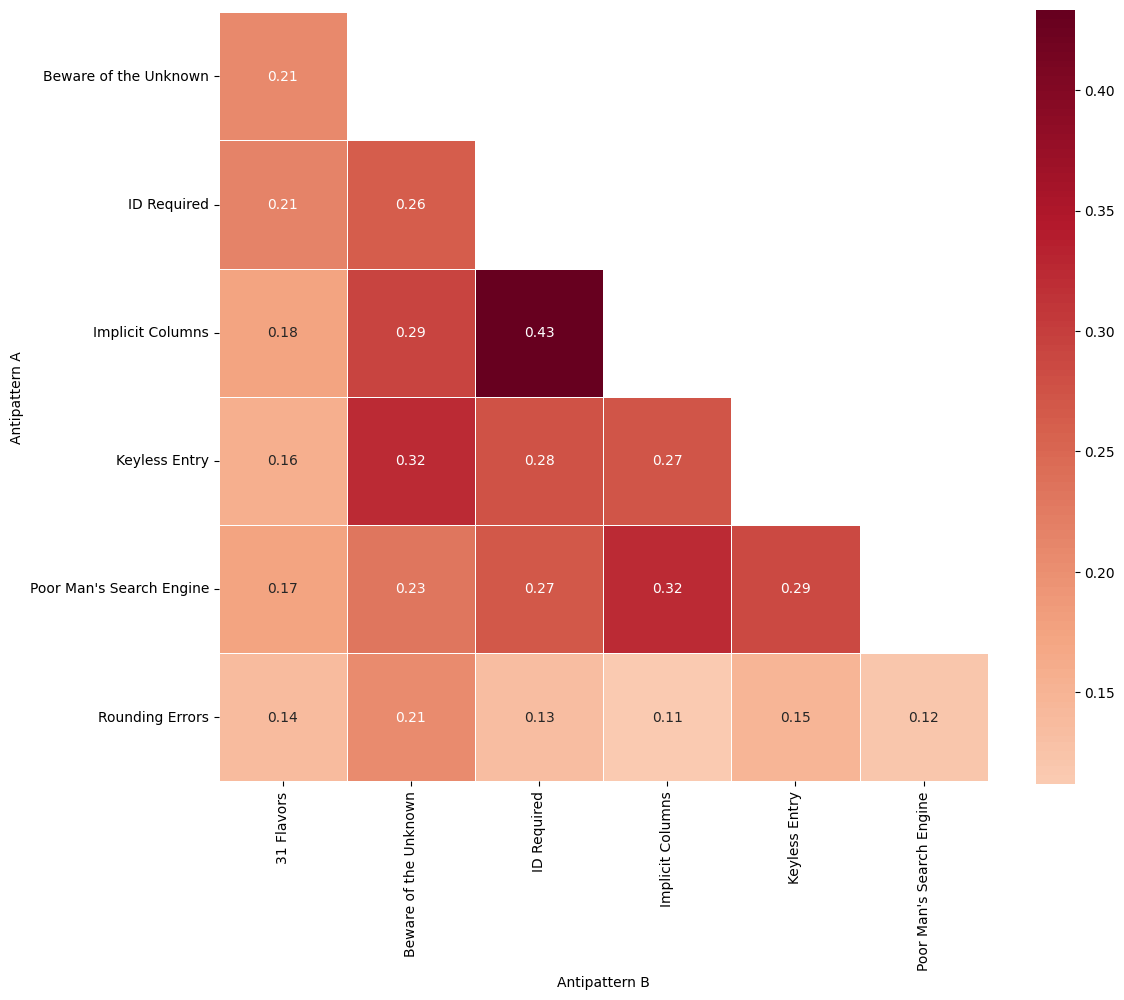

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a matrix of RAW COUNTS per Project
project_counts = (
    results_df.groupby(["Project", "Antipattern"])
    .size()
    .unstack(fill_value=0)
)

# 2. Calculate Spearman Correlation
# .corr(method='spearman') calculates pairwise correlation between columns
spearman_proj = project_counts.corr(method='spearman')

# 3. Mask the upper triangle and diagonal for a clean look
mask = np.triu(np.ones_like(spearman_proj, dtype=bool))
plot_df = spearman_proj.iloc[1:, :-1]
plot_mask = mask[1:, :-1]

# 4. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    plot_df, 
    mask=plot_mask,
    annot=True, 
    cmap="RdBu_r", 
    center=0,      # Zero is neutral (white)
    fmt=".2f", 
    square=True,
    linewidths=.5
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.tight_layout()
plt.show()

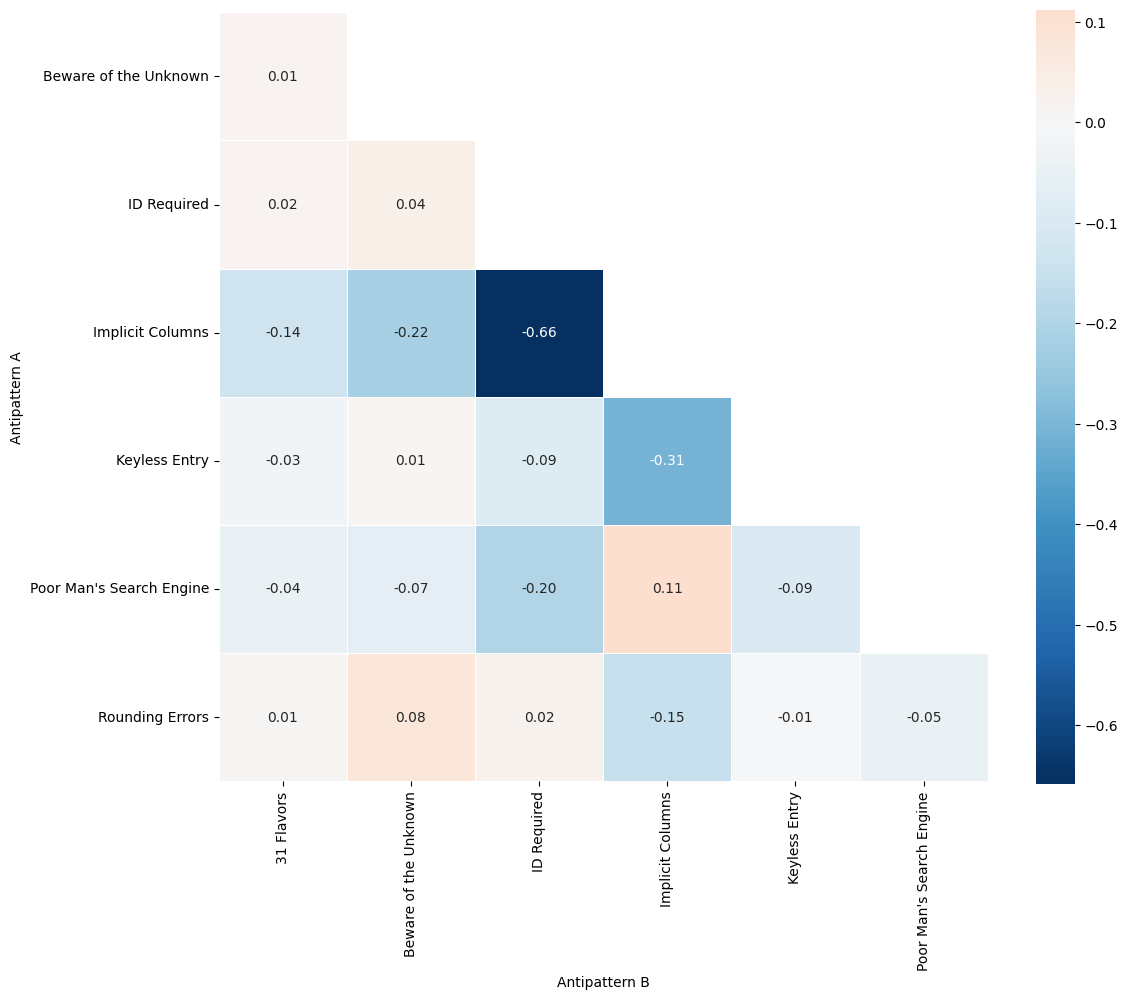

In [72]:
# 1. Create a matrix of RAW COUNTS per File
file_counts = (
    results_df.groupby(["Project", "File", "Antipattern"])
    .size()
    .unstack(fill_value=0)
)

# 2. Calculate Spearman Correlation
spearman_file = file_counts.corr(method='spearman')

# 3. Mask and Slice
mask_file = np.triu(np.ones_like(spearman_file, dtype=bool))
plot_file_df = spearman_file.iloc[1:, :-1]
plot_file_mask = mask_file[1:, :-1]

# 4. Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(
    plot_file_df, 
    mask=plot_file_mask,
    annot=True, 
    cmap="RdBu_r", 
    center=0,
    fmt=".2f", 
    square=True,
    linewidths=.5
)

plt.ylabel("Antipattern A")
plt.xlabel("Antipattern B")
plt.tight_layout()
plt.show()